# Projet TB Traitement d'images 
Hippolyte Valentin

### 1. Import des bibliothèques

In [39]:
# Bibliothèques de base
import numpy as np
import matplotlib.pyplot as plt
import os

# Chargement et manipulation d'images
import skimage.io
import skimage.color

# Traitements d'images
import skimage.exposure
import skimage.filters
import skimage.morphology
import scipy.ndimage

### 2. Chargement de l'image et détection de son type

Je fais cela car j'ai crée 3 pipelines selon si l'image a testé est binaire, en couleur, ou en nuance de gris. 

Chargement de l'image

In [ ]:
# Chemins des 3 images de test — modifier ici si besoin
IMAGE_COULEUR = r'C:\Users\Hippolyte\Desktop\TB Images\Images\retine.png'
IMAGE_GRIS    = r'C:\Users\Hippolyte\Desktop\TB Images\Images\lena256.bmp'
IMAGE_BINAIRE = r'C:\Users\Hippolyte\Desktop\TB Images\Images\bat-5.png'

In [ ]:
img_raw = skimage.io.imread(IMAGE_COULEUR)

def detecter_type_image(image):
    if image.ndim == 3 and image.shape[2] in (3, 4):
        return 'couleur'
    if len(np.unique(image)) <= 2:
        return 'binaire'
    return 'niveaux de gris'

type_image = detecter_type_image(img_raw)

hauteur, largeur = img_raw.shape[:2]
nb_canaux = img_raw.shape[2] if img_raw.ndim == 3 else 1

print("  Caractéristiques de l'image")
print(f"Dimensions (H x L)   : {hauteur} x {largeur} pixels")
print(f"Nombre de canaux     : {nb_canaux}")
print(f"Type de données      : {img_raw.dtype}")
print(f"Intensité Min / Max  : {np.min(img_raw)} / {np.max(img_raw)}")
print(f"Type détecté         : {type_image.upper()}")

plt.figure(figsize=(6, 6))
plt.imshow(img_raw, cmap=None if img_raw.ndim == 3 else 'gray')
plt.title("Image originale")
plt.axis('off')
plt.show()

---
### 3. Traitement de l'image et analyse



## Si Image COULEUR (RGB)

In [ ]:
if type_image == 'couleur':
    img_gray_c = skimage.color.rgb2gray(img_raw[:, :, :3])
    img_gray_c = (img_gray_c * 255).astype(np.uint8)

On crée une version de l'image en niveaux de gris car les algorithmes d'Otsu et Sobel ne peuvent pas s'appliquer sur une image à 3 canaux.

#### Opération 1 — Histogramme 

In [ ]:
if type_image == 'couleur':
    # On sépare l'histogramme par canal car un histogramme global fusionnerait R, G, B et masquerait les déséquilibres de couleur.
    def op1_histogram_couleur(img):
        """Histogramme séparé pour chaque canal Rouge, Vert, Bleu."""
        fig, ax = plt.subplots(figsize=(8, 3))
        for canal, couleur, label in zip(range(3), ['red', 'green', 'blue'], ['Rouge', 'Vert', 'Bleu']):
            ax.hist(img[:, :, canal].ravel(), bins=256, range=(0, 256), color=couleur, alpha=0.5, label=label)
        ax.set_title("Histogramme des canaux R, G, B")
        ax.set_xlabel("Intensité")
        ax.set_ylabel("Pixels")
        ax.legend()
        ax.grid(alpha=0.3)
        return fig

    fig = op1_histogram_couleur(img_raw)
    plt.show()

#### Opération 2 — Filtrage Médian (canal par canal)

J'ai hésité avec le filtre gaussien mais je me suis tourné vers le filtre médian car:
- Préserve les contours contrairement au gaussien
- Traite efficacement le bruit
- Facilité d'implémentation

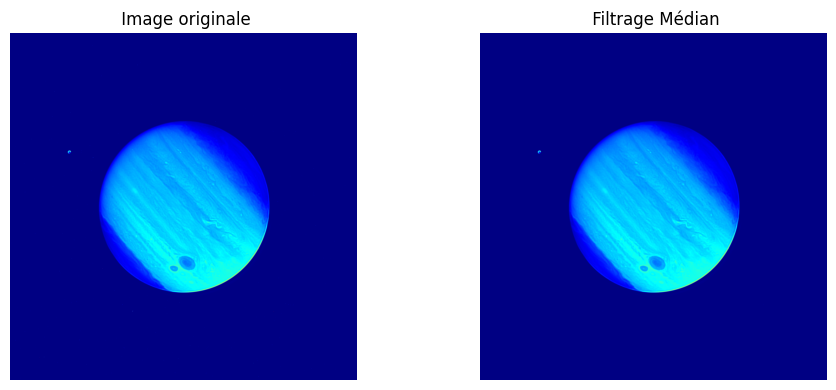

In [ ]:
if type_image == 'couleur':
    
    def op2_median_filter_couleur(img):
        """Filtre médian appliqué indépendamment sur chaque canal R, G, B."""
        img_filtered = np.zeros_like(img[:,:, :3])
        for i in range(3):
            img_filtered[:,:, i] = scipy.ndimage.median_filter(img[:,:, i], size=3)
        return img_filtered

    img_filtered_c = op2_median_filter_couleur(img_raw)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_raw)
    ax1.set_title(" Image originale")
    ax1.axis('off')
    ax2.imshow(img_filtered_c)
    ax2.set_title(" Filtrage Médian")
    ax2.axis('off')
    plt.tight_layout()
    plt.show()

#### Opération 3 — Égalisation du contraste (canal luminosité HSV)

On convertit l'image en HSV pour pouvoir agir uniquement sur la luminosité sans toucher aux couleurs. Ainsi, l'égalisation améliore le contraste global de l'image tout en préservant les teintes originales.

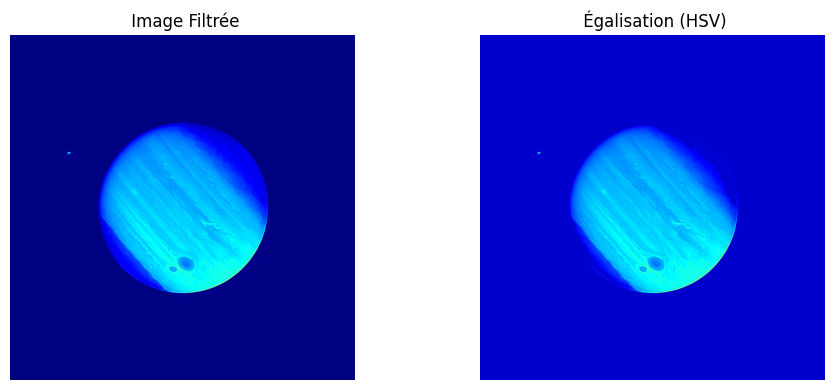

In [41]:
if type_image == 'couleur':
    def op3_equalization_couleur(img):
        """Égalise uniquement la luminosité (canal V dans l'espace HSV) pour préserver les couleurs."""
        img_hsv = skimage.color.rgb2hsv(img[:, :, :3])
        img_hsv[:, :, 2] = skimage.exposure.equalize_hist(img_hsv[:, :, 2])
        return (skimage.color.hsv2rgb(img_hsv) * 255).astype(np.uint8)

    img_eq_c = op3_equalization_couleur(img_filtered_c)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_filtered_c)
    ax1.set_title(" Image Filtrée")
    ax1.axis('off')
    ax2.imshow(img_eq_c)
    ax2.set_title(" Égalisation (HSV)")
    ax2.axis('off')
    plt.tight_layout()
    plt.show()

#### Opération 4 — Seuillage d'Otsu (binarisation)

 On utilise Otsu pour séparer automatiquement les objets du fond, sans avoir à choisir le seuil manuellement.
Ici on utilise Otsu et pas un K-means car on a seulement 2 classes à distinguer, K-means serait superflu.

Seuil d'Otsu calculé : 81.000


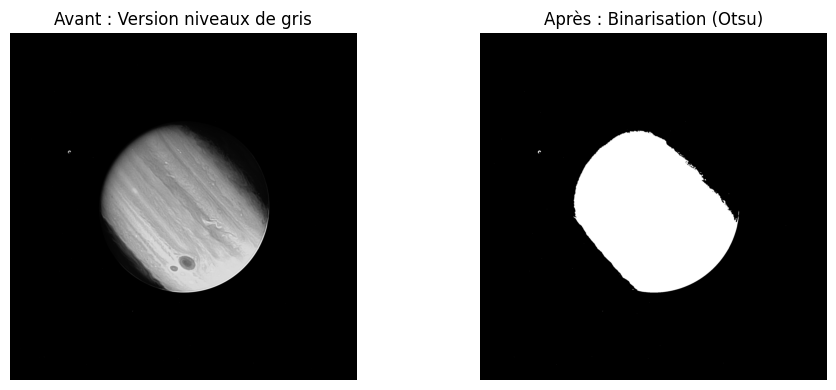

In [ ]:
if type_image == 'couleur':

    def op4_otsu_thresholding_c(img_gray):

        """Seuillage d'Otsu sur la version en niveaux de gris."""
        threshold = skimage.filters.threshold_otsu(img_gray)
        return img_gray > threshold, threshold


    img_binary_c, otsu_thresh_c = op4_otsu_thresholding_c(img_gray_c)
    print(f"Seuil d'Otsu calculé : {otsu_thresh_c:.3f}")


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_gray_c, cmap='gray')
    ax1.set_title("Avant : Version niveaux de gris")
    ax1.axis('off')
    ax2.imshow(img_binary_c, cmap='gray')
    ax2.set_title("Après : Binarisation (Otsu)")
    ax2.axis('off')
    plt.tight_layout()
    plt.show()

#### Opération 5 — Ouverture Morphologique (nettoyage)

 On utilise l'ouverture morphologique pour supprimer les pixels isolés apparus après binarisation, sans modifier les objets principaux.

In [ ]:
if type_image == 'couleur':

    def op5_morphological_opening_c(img_binary):
        """Supprime les petits îlots de bruit isolés après binarisation."""
        selem = skimage.morphology.disk(2)
        return skimage.morphology.opening(img_binary, selem)


    img_opened_c = op5_morphological_opening_c(img_binary_c)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_binary_c, cmap='gray')
    ax1.set_title(" Avant: Binarisation brute")
    ax1.axis('off')
    ax2.imshow(img_opened_c, cmap='gray')
    ax2.set_title("Après ouverture Morphologique")
    ax2.axis('off')
    plt.tight_layout()
    plt.show()

#### Opération 6 — Détection de contours (Filtre de Sobel)

On utilise Sobel pour détecter les contours des structures sur la version en niveaux de gris.

In [ ]:
if type_image == 'couleur':
    
    def op6_sobel_filter_c(img_gray):
        """Détecte les contours sur la version en niveaux de gris."""
        return skimage.filters.sobel(img_gray)

    img_sobel_c = op6_sobel_filter_c(img_gray_c)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_sobel_c, cmap='gray')
    plt.title("Résultat : Filtre de Sobel (contours)")
    plt.axis('off')
    plt.show()

---
## Si Image  en niveaux de gris

In [ ]:
# Chargement de l'image niveaux de gris pour cette section
img_raw = skimage.io.imread(IMAGE_GRIS)
type_image = 'niveaux de gris'
print(f"Image chargée : {IMAGE_GRIS}  —  {img_raw.shape}  |  {img_raw.dtype}")

In [ ]:
if type_image == 'niveaux de gris':
    # On la mets en uint8 pour s'assurer que les opérations  fonctionnent correctement
    img_gray = img_raw.astype(np.uint8)

#### Opération 1 — Histogramme des intensités

In [ ]:
if type_image == 'niveaux de gris':
    
    def op1_histogram(img_gray):
        """Histogramme des niveaux d'intensité."""
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.hist(img_gray.ravel(), bins=256, range=(0, 256), color='black', alpha=0.7)
        ax.set_title("Histogramme des intensités")
        ax.set_xlabel("Intensité")
        ax.set_ylabel("Pixels")
        ax.grid(alpha=0.3)
        return fig

    fig = op1_histogram(img_gray)
    plt.show()

#### Opération 2 — Filtrage Médian 

In [ ]:
if type_image == 'niveaux de gris':
    
    def op2_median_filter(img_gray):
        return scipy.ndimage.median_filter(img_gray, size=3)

    img_filtered = op2_median_filter(img_gray)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_gray, cmap='gray')
    ax1.set_title("Avant avec Niveaux de gris")
    ax1.axis('off')
    ax2.imshow(img_filtered, cmap='gray')
    ax2.set_title("Après avec Filtrage Médian")
    ax2.axis('off')
    plt.tight_layout()
    plt.show()

#### Opération 3 — Égalisation d'histogramme (amélioration du contraste)

 L'égalisation redistribue uniformément les niveaux d'intensité pour améliorer le contraste global avant la segmentation.


In [ ]:
if type_image == 'niveaux de gris':
    
    def op3_equalization(img_filtered):
        """Améliore le contraste en redistribuant uniformément les niveaux d'intensité."""
        img_eq = skimage.exposure.equalize_hist(img_filtered)
        return (img_eq * 255).astype(np.uint8)

    img_eq = op3_equalization(img_filtered)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_filtered, cmap='gray')
    ax1.set_title("Avant : Image Filtrée")
    ax1.axis('off')
    ax2.imshow(img_eq, cmap='gray')
    ax2.set_title("Après : Égalisation")
    ax2.axis('off')
    plt.tight_layout()
    plt.show()

#### Opération 4 — Seuillage d'Otsu (binarisation)

In [ ]:
if type_image == 'niveaux de gris':
    
    def op4_otsu_thresholding(img_eq):
        """Sépare automatiquement le premier plan du fond en trouvant le seuil optimal."""
        threshold = skimage.filters.threshold_otsu(img_eq)
        return img_eq > threshold, threshold

    img_binary, otsu_thresh = op4_otsu_thresholding(img_eq)
    print(f"Seuil d'Otsu calculé : {otsu_thresh:.3f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_eq, cmap='gray')
    ax1.set_title("Avant : Image Égalisée")
    ax1.axis('off')
    ax2.imshow(img_binary.astype(float), cmap='gray')
    ax2.set_title("Après : Binarisation (Otsu)")
    ax2.axis('off')
    plt.tight_layout()
    plt.show()

#### Opération 5 — Ouverture Morphologique (nettoyage)

In [ ]:
if type_image == 'niveaux de gris':
    
    def op5_morphological_opening(img_binary):
        """Supprime les petits îlots de bruit isolés après binarisation."""
        selem = skimage.morphology.disk(2)
        return skimage.morphology.opening(img_binary, selem)

    img_opened = op5_morphological_opening(img_binary)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_binary.astype(float), cmap='gray')
    ax1.set_title("Avant : Binarisation brute")
    ax1.axis('off')
    ax2.imshow(img_opened.astype(float), cmap='gray')
    ax2.set_title("Après : Ouverture Morphologique")
    ax2.axis('off')
    plt.tight_layout()
    plt.show()

#### Opération 6 — Détection de contours (Filtre de Sobel)

In [ ]:
if type_image == 'niveaux de gris':
    
    def op6_sobel_filter(img_eq):
        """Met en évidence les bordures et frontières des objets."""
        return skimage.filters.sobel(img_eq)

    img_sobel = op6_sobel_filter(img_eq)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_sobel, cmap='gray')
    plt.title("Résultat : Filtre de Sobel (contours)")
    plt.axis('off')
    plt.show()

---
## Si on a une image binaire

In [ ]:
# Chargement de l'image binaire pour cette section
img_raw = skimage.io.imread(IMAGE_BINAIRE)
type_image = 'binaire'
print(f"Image chargée : {IMAGE_BINAIRE}  —  {img_raw.shape}  |  {img_raw.dtype}")

Normalisation en booléen 


In [ ]:
if type_image == 'binaire':
    img_bin = img_raw > 0

#### Opération 1 — Comptage des pixels (blanc / noir)

 Un histogramme est inutile dans ce cas sur une image binaire car on a seulement 2 valeurs. A la palce on peut effectuer un compate des pixels pour quantifier les objets.

In [ ]:
if type_image == 'binaire':

    def op1_pixel_count(img_bin):
        nb_blancs = int(np.sum(img_bin))
        nb_noirs = img_bin.size - nb_blancs

        fig, ax = plt.subplots(figsize=(5, 3))
        ax.bar(['Pixels blancs (objets)', 'Pixels noirs (fond)'], [nb_blancs, nb_noirs], color=['white', 'black'], edgecolor='gray')
        ax.set_title("Répartition des pixels")
        ax.set_ylabel("Nombre de pixels")
        ax.set_facecolor('#eeeeee')
        print(f"Pixels blancs : {nb_blancs} ({100*nb_blancs/img_bin.size:.1f}%)")
        print(f"Pixels noirs  : {nb_noirs} ({100*nb_noirs/img_bin.size:.1f}%)")
        
        return fig

    fig = op1_pixel_count(img_bin)
    plt.show()

#### Opération 2 — Fermeture Morphologique (combler les trous)

Contrairement à l'ouverture utilisée avec une image en niveaux de gris (érosion puis dilatation), on commence ici par une fermeture (dilatation puis érosion) car l'image binaire peut contenir des trous à l'intérieur des objets. La fermeture est sensée combler les trous sans modifier la forme globale des objets

In [ ]:
if type_image == 'binaire':

    def op2_morphological_closing(img_bin):
        selem = skimage.morphology.disk(2)
        return skimage.morphology.closing(img_bin, selem)

    img_closed = op2_morphological_closing(img_bin)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_bin, cmap='gray')
    ax1.set_title("Avant : Image Binaire")
    ax1.axis('off')
    ax2.imshow(img_closed, cmap='gray')
    ax2.set_title("Après : Fermeture Morphologique")
    ax2.axis('off')
    plt.tight_layout()
    plt.show()

#### Opération 3 — Dilatation (agrandir les objets)

 La dilatation agrandit légèrement les objets pour mieux visualiser leur étendue avant l'analyse de structure.


In [ ]:
if type_image == 'binaire':
    def op3_dilation(img_bin):
        """Agrandit légèrement les objets blancs pour mieux visualiser leur étendue."""
        selem = skimage.morphology.disk(2)
        return skimage.morphology.dilation(img_bin, selem)

    img_dilated = op3_dilation(img_closed)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_closed, cmap='gray')
    ax1.set_title("Avant : Fermeture")
    ax1.axis('off')
    ax2.imshow(img_dilated, cmap='gray')
    ax2.set_title("Après : Dilatation")
    ax2.axis('off')
    plt.tight_layout()
    plt.show()

#### Opération 4 — Squelettisation (structure fine des objets)

 La squelettisation réduit chaque objet à son axe central. C'est utile pour compter, mesurer ou comparer des formes biologiques.


In [ ]:
if type_image == 'binaire':
    def op4_skeletonize(img_bin):
        return skimage.morphology.skeletonize(img_bin)

    img_skeleton = op4_skeletonize(img_dilated)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_dilated, cmap='gray')
    ax1.set_title("Avant : Dilatation")
    ax1.axis('off')
    ax2.imshow(img_skeleton, cmap='gray')
    ax2.set_title("Après : Squelettisation")
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

#### Opération 5 — Ouverture Morphologique (nettoyage)

Après la dilatation et la squelettisation, certains petits pixels isolés peuvent rester en dehors des objets principaux. On fait donc une ouverture morphologique pour les éliminer et obtenir une image propre avant la détection des contours

In [ ]:
if type_image == 'binaire':
    
    def op5_morphological_opening_b(img_bin):
        selem = skimage.morphology.disk(2)
        return skimage.morphology.opening(img_bin, selem)

    img_opened_b = op5_morphological_opening_b(img_bin)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_bin, cmap='gray')
    ax1.set_title("Avant : Image Binaire")
    ax1.axis('off')
    ax2.imshow(img_opened_b, cmap='gray')
    ax2.set_title("Après : Ouverture Morphologique")
    ax2.axis('off')
    plt.tight_layout()
    plt.show()

#### Opération 6 — Détection de contours (Filtre de Sobel)

On applique Sobel sur l'image binaire nettoyée pour mettre en évidence les frontières exactes des objets.


In [ ]:
if type_image == 'binaire':
    def op6_sobel_filter_b(img_bin):
        return skimage.filters.sobel(img_bin.astype(np.uint8))

    img_sobel_b = op6_sobel_filter_b(img_opened_b)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_sobel_b, cmap='gray')
    plt.title("Résultat : Filtre de Sobel (contours)")
    plt.axis('off')
    plt.show()

---
## 4. Génération des images PNG et du fichier LaTeX

Cette section :
1. Crée un dossier `rapport_latex/` avec un sous-dossier `images/`
2. Génère un PNG pour chaque opération de chaque pipeline (couleur, niveaux de gris, binaire)
3. Génère un fichier `rapport.tex` prêt à être compilé dans Overleaf

Il ne reste qu'à uploader le dossier `rapport_latex/` (avec le `.tex` et le sous-dossier `images/`) sur Overleaf.

In [28]:
# ─────────────────────────────────────────────────────────────────────────
# Dossier de sortie
# ─────────────────────────────────────────────────────────────────────────
DOSSIER       = 'rapport_latex'
DOSSIER_IMG   = os.path.join(DOSSIER, 'images')
os.makedirs(DOSSIER_IMG, exist_ok=True)

selem = skimage.morphology.disk(2)

def sauver(fig, nom):
    """Enregistre une figure matplotlib en PNG dans le dossier images/."""
    chemin = os.path.join(DOSSIER_IMG, nom + '.png')
    fig.savefig(chemin, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  → {chemin}")

# ─────────────────────────────────────────────────────────────────────────
# Pipeline COULEUR — applique sur retine.png
# ─────────────────────────────────────────────────────────────────────────
print("Génération des images COULEUR...")
img       = skimage.io.imread(IMAGE_COULEUR)
img_gray  = (skimage.color.rgb2gray(img[:, :, :3]) * 255).astype(np.uint8)
img_filt  = np.zeros_like(img[:, :, :3])
for i in range(3):
    img_filt[:, :, i] = scipy.ndimage.median_filter(img[:, :, i], size=3)
img_hsv        = skimage.color.rgb2hsv(img_filt.astype(float) / 255.0)
img_hsv[:,:,2] = skimage.exposure.equalize_hist(img_hsv[:,:,2])
img_eq    = (skimage.color.hsv2rgb(img_hsv) * 255).astype(np.uint8)
thresh_c  = skimage.filters.threshold_otsu(img_gray)
img_bin   = img_gray > thresh_c
img_open  = skimage.morphology.opening(img_bin, selem)
img_sobel = skimage.filters.sobel(img_gray)

# Original
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img); ax.axis('off'); sauver(fig, 'couleur_00_original')
# Op.1 Histogramme R,G,B
fig, ax = plt.subplots(figsize=(7, 3.5))
for c, col, lbl in zip(range(3), ['red','green','blue'], ['Rouge','Vert','Bleu']):
    ax.hist(img[:,:,c].ravel(), bins=256, range=(0,256), color=col, alpha=0.5, label=lbl)
ax.set_xlabel("Intensité"); ax.set_ylabel("Pixels"); ax.legend(); ax.grid(alpha=0.3)
sauver(fig, 'couleur_01_histogramme')
# Op.2 Filtrage médian
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_filt);  ax.axis('off'); sauver(fig, 'couleur_02_median')
# Op.3 Égalisation HSV
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_eq);    ax.axis('off'); sauver(fig, 'couleur_03_egalisation')
# Op.4 Otsu
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_bin,   cmap='gray'); ax.axis('off'); sauver(fig, 'couleur_04_otsu')
# Op.5 Ouverture
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_open,  cmap='gray'); ax.axis('off'); sauver(fig, 'couleur_05_ouverture')
# Op.6 Sobel
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_sobel, cmap='gray'); ax.axis('off'); sauver(fig, 'couleur_06_sobel')

# ─────────────────────────────────────────────────────────────────────────
# Pipeline NIVEAUX DE GRIS — applique sur lena256.bmp
# ─────────────────────────────────────────────────────────────────────────
print("\nGénération des images NIVEAUX DE GRIS...")
img       = skimage.io.imread(IMAGE_GRIS)
img_gray  = img.astype(np.uint8)
img_filt  = scipy.ndimage.median_filter(img_gray, size=3)
img_eq    = (skimage.exposure.equalize_hist(img_filt) * 255).astype(np.uint8)
thresh_g  = skimage.filters.threshold_otsu(img_eq)
img_bin   = img_eq > thresh_g
img_open  = skimage.morphology.opening(img_bin, selem)
img_sobel = skimage.filters.sobel(img_eq)

# Original
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_gray, cmap='gray'); ax.axis('off'); sauver(fig, 'gris_00_original')
# Op.1 Histogramme
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(img_gray.ravel(), bins=256, range=(0,256), color='black', alpha=0.7)
ax.set_xlabel("Intensité"); ax.set_ylabel("Pixels"); ax.grid(alpha=0.3)
sauver(fig, 'gris_01_histogramme')
# Op.2 Filtrage médian
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_filt,  cmap='gray'); ax.axis('off'); sauver(fig, 'gris_02_median')
# Op.3 Égalisation
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_eq,    cmap='gray'); ax.axis('off'); sauver(fig, 'gris_03_egalisation')
# Op.4 Otsu
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_bin.astype(float),  cmap='gray'); ax.axis('off'); sauver(fig, 'gris_04_otsu')
# Op.5 Ouverture
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_open.astype(float), cmap='gray'); ax.axis('off'); sauver(fig, 'gris_05_ouverture')
# Op.6 Sobel
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_sobel, cmap='gray'); ax.axis('off'); sauver(fig, 'gris_06_sobel')

# ─────────────────────────────────────────────────────────────────────────
# Pipeline BINAIRE — applique sur bat-5.png
# ─────────────────────────────────────────────────────────────────────────
print("\nGénération des images BINAIRE...")
img         = skimage.io.imread(IMAGE_BINAIRE)
img_bin     = img > 0
img_closed  = skimage.morphology.closing(img_bin, selem)
img_dilated = skimage.morphology.dilation(img_closed, selem)
img_skel    = skimage.morphology.skeletonize(img_dilated)
img_open    = skimage.morphology.opening(img_bin, selem)
img_sobel   = skimage.filters.sobel(img_open.astype(np.uint8))
nb_b        = int(np.sum(img_bin)); nb_n = img_bin.size - nb_b

# Original
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_bin.astype(float), cmap='gray'); ax.axis('off'); sauver(fig, 'binaire_00_original')
# Op.1 Comptage pixels
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['Pixels blancs (objets)', 'Pixels noirs (fond)'], [nb_b, nb_n], color=['white', 'black'], edgecolor='gray')
ax.set_ylabel("Nombre de pixels"); ax.set_facecolor('#eeeeee')
ax.set_title(f"{100*nb_b/img_bin.size:.1f}% blancs / {100*nb_n/img_bin.size:.1f}% noirs")
sauver(fig, 'binaire_01_comptage')
# Op.2 Fermeture
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_closed.astype(float),  cmap='gray'); ax.axis('off'); sauver(fig, 'binaire_02_fermeture')
# Op.3 Dilatation
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_dilated.astype(float), cmap='gray'); ax.axis('off'); sauver(fig, 'binaire_03_dilatation')
# Op.4 Squelettisation
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_skel.astype(float),    cmap='gray'); ax.axis('off'); sauver(fig, 'binaire_04_squelette')
# Op.5 Ouverture
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_open.astype(float),    cmap='gray'); ax.axis('off'); sauver(fig, 'binaire_05_ouverture')
# Op.6 Sobel
fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img_sobel,                 cmap='gray'); ax.axis('off'); sauver(fig, 'binaire_06_sobel')

print(f"\nToutes les images sont dans : {DOSSIER_IMG}")
print(f"Seuil Otsu couleur : {thresh_c:.0f}")
print(f"Seuil Otsu gris    : {thresh_g:.0f}")

Génération des images COULEUR...
  → rapport_latex\images\couleur_00_original.png
  → rapport_latex\images\couleur_01_histogramme.png
  → rapport_latex\images\couleur_02_median.png
  → rapport_latex\images\couleur_03_egalisation.png
  → rapport_latex\images\couleur_04_otsu.png
  → rapport_latex\images\couleur_05_ouverture.png
  → rapport_latex\images\couleur_06_sobel.png

Génération des images NIVEAUX DE GRIS...
  → rapport_latex\images\gris_00_original.png
  → rapport_latex\images\gris_01_histogramme.png
  → rapport_latex\images\gris_02_median.png
  → rapport_latex\images\gris_03_egalisation.png
  → rapport_latex\images\gris_04_otsu.png
  → rapport_latex\images\gris_05_ouverture.png
  → rapport_latex\images\gris_06_sobel.png

Génération des images BINAIRE...
  → rapport_latex\images\binaire_00_original.png
  → rapport_latex\images\binaire_01_comptage.png
  → rapport_latex\images\binaire_02_fermeture.png
  → rapport_latex\images\binaire_03_dilatation.png
  → rapport_latex\images\binair